# 01 · Air-Source Heat Pump (ASHP) CEA Greenhouse Simulation
### Dynamic 52,560-Hour (6-Year) Two-Stage Ammonia Heat Pump Model with Flash Tank Economizer

**Author**: Fraser James Mclellan  
**Academic Basis**: BEng (Hons) Individual Project Thesis (Grade A4, First-Class Honours), University of Glasgow  
**Domain**: Controlled Environment Agriculture (CEA) & Low-Carbon Industrial Heating  

---

## 1. Thermodynamic & Physical Boundary Conditions

This simulation models the hourly thermal dynamics of a commercial CEA greenhouse located in Chelmsford, Essex, UK over a 6-year period (2018–2024, 52,560 continuous hourly steps).

### Greenhouse Envelope Specifications:
- **Footprint**: $20\,\text{m} \times 20\,\text{m}$, eaves height $5\,\text{m}$ (Volume $V = 2,000\,\text{m}^3$, total wall/roof surface area $A_{\text{wall}} = 800\,\text{m}^2$, ground area $A_{\text{ground}} = 400\,\text{m}^2$).
- **Thermal Conductance (Envelope)**: Multi-wall polycarbonate/PVC panels, $U_{\text{wall}} = 3.0\,\text{W/(m}^2\text{K)}$.
- **Thermal Conductance (Floor)**: Insulated ground floor, $U_{\text{ground}} = 1.2\,\text{W/(m}^2\text{K)}$.
- **Solar Transmittance**: $\tau = 0.70$ (70% of incident global horizontal irradiance transferred to internal air volume).
- **Target Climate Setpoint**: Continuous temperature clamped at $T_{\text{internal}} = 18.0^\circ\text{C}$.

### Heat Pump Cycle Architecture:
- **Refrigerant**: Natural Ammonia ($NH_3$ / R-717, $ODP = 0, GWP = 0$).
- **Cycle Topology**: Two-stage vapor-compression with intermediate flash-tank economizer:
  1. Evaporator at $T_1 = T_{\text{ambient}} - \Delta T_{\text{pinch}}$ (saturated vapor).
  2. Low-stage compressor elevating vapor from $P_1$ to intermediate flash pressure $P_{\text{int}} = \sqrt{P_{\text{evap}} \cdot P_{\text{cond}}}$.
  3. Flash tank vapor separation: flash gas mixes with low-stage discharge before entering high-stage compressor.
  4. High-stage compressor elevating refrigerant to condenser pressure $P_{\text{cond}}$ (condensing temperature $T_5 = 80^\circ\text{C}$ to supply high-temperature hydronic greenhouse heating loops).
  5. Dual throttling valves regulating flash tank and evaporator expansion.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Apply publication-quality visual styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 14,
    'lines.linewidth': 1.6,
    'figure.dpi': 150
})

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Model Implementations
We define the thermodynamic classes that model greenhouse heat losses, refrigerant property extractions from databook tables, and two-stage cycle state-point solving.


In [2]:
class GreenhouseThermalBalance:
    """Calculates building envelope heat losses, solar gains, and net heating demand."""
    def __init__(self, k_wall=3.0, k_ground=1.2, A_wall=800.0, A_ground=400.0, 
                 d_wall=0.01, d_ground=0.1, V=2000.0, rho_air=1.225, cp_air=1005.0, 
                 desired_temp=18.0, tau=0.7):
        self.k_wall = k_wall
        self.k_ground = k_ground
        self.A_wall = A_wall
        self.A_ground = A_ground
        self.d_wall = d_wall
        self.d_ground = d_ground
        self.m = V * rho_air # Air mass in greenhouse (kg)
        self.c = cp_air      # Specific heat capacity (J/(kg*K))
        self.desired_temp = desired_temp
        self.tau = tau

    def calculate_losses(self, T_internal, external_temp, ground_temp, solar_W):
        """Hourly steady-state envelope heat flux balance."""
        Q_wall = (self.k_wall * self.A_wall / self.d_wall) * (external_temp - T_internal)
        Q_ground = (self.k_ground * self.A_ground / self.d_ground) * (ground_temp - T_internal)
        Q_sun = solar_W * self.A_ground * self.tau
        Q_net = Q_wall + Q_ground + Q_sun # Net heat flux into volume (W)
        return Q_wall, Q_ground, Q_sun, Q_net

    def required_heat_demand(self, T_unconditioned):
        """Heat energy required (Joules/hr) to restore temperature to 18.0 °C."""
        if T_unconditioned < self.desired_temp:
            delta_T = self.desired_temp - T_unconditioned
            Q_c_Joules = self.m * self.c * delta_T
            return Q_c_Joules
        return 0.0

class AmmoniaProperties:
    """Extracts thermodynamic properties of R-717 from tabulated databooks."""
    def __init__(self, sat_path, sh_path):
        self.df_sat = pd.read_csv(sat_path)
        self.df_sh = pd.read_csv(sh_path)

    def get_cycle_states(self, T_evap, T_cond=80.0):
        """Solves state points 1 through 7 for a two-stage flash-tank cycle."""
        # 1. State 1: Saturated vapor at evaporator temperature
        row1 = self.df_sat.iloc[(self.df_sat['Temp'] - T_evap).abs().argsort()[:1]].iloc[0]
        P_1 = row1['Pressure']
        h_1 = row1['enthalpy vapour']
        s_1 = row1['Entropy Vapour']

        # 2. State 5: Saturated liquid leaving condenser (T_cond = 80 °C)
        row5 = self.df_sat.iloc[(self.df_sat['Temp'] - T_cond).abs().argsort()[:1]].iloc[0]
        P_5 = row5['Pressure']
        h_5 = row5['Enthalpy liquid']
        s_5 = row5['Entropy liquid']

        # 3. Intermediate flash pressure: geometric mean
        P_int = np.sqrt(P_1 * P_5)
        row3 = self.df_sat.iloc[(self.df_sat['Pressure'] - P_int).abs().argsort()[:1]].iloc[0]
        T_3 = row3['Temp']
        h_3 = row3['enthalpy vapour']
        s_3 = row3['Entropy Vapour']

        # 4. State 2: High-pressure discharge from Stage 1 (isentropic s2 = s1 at P_int)
        sh_sub2 = self.df_sh[(self.df_sh['pressure'] - P_int).abs() < 50.0]
        if sh_sub2.empty:
            sh_sub2 = self.df_sh
        row2 = sh_sub2.iloc[((sh_sub2['pressure'] - P_int).abs() + (sh_sub2['entropy'] - s_1).abs()*100).argsort()[:1]].iloc[0]
        h_2 = row2['enthalpy']

        # 5. State 4: High-stage compressor discharge (isentropic s4 = s3 at P_5)
        sh_sub4 = self.df_sh[(self.df_sh['pressure'] - P_5).abs() < 50.0]
        if sh_sub4.empty:
            sh_sub4 = self.df_sh
        row4 = sh_sub4.iloc[((sh_sub4['pressure'] - P_5).abs() + (sh_sub4['entropy'] - s_3).abs()*100).argsort()[:1]].iloc[0]
        h_4 = row4['enthalpy']

        # Throttling stages
        h_7 = h_5 # Throttled to evaporator pressure

        return {
            'P_1': P_1, 'P_int': P_int, 'P_5': P_5,
            'h_1': h_1, 'h_2': h_2, 'h_3': h_3, 'h_4': h_4, 'h_5': h_5, 'h_7': h_7,
            's_1': s_1, 's_3': s_3
        }

print("Thermal and thermodynamic models instantiated.")


Thermal and thermodynamic models instantiated.


## 3. Load Datasets & Results
We import the hourly Chelmsford weather dataset and the 52,560-hour pre-computed simulation outputs.


In [3]:
data_dir = '../data'
df_weather = pd.read_csv(f'{data_dir}/inputs/air_temperature_hourly_2018_2024.csv')
df_sat = f'{data_dir}/inputs/saturated_ammonia.csv'
df_sh = f'{data_dir}/inputs/superheated_ammonia.csv'

# Load verified 52,560-hour ASHP simulation outputs
df_as = pd.read_csv(f'{data_dir}/outputs/results_air_source.csv')
df_hl = pd.read_csv(f'{data_dir}/outputs/greenhouse_heat_load.csv')

print(f"Loaded 52,560-hour ASHP simulation records. Shape: {df_as.shape}")
df_as.head()


Loaded 52,560-hour ASHP simulation records. Shape: (52560, 10)


,hour,time_days,Q_c_W,Q_e_kW,W_c1_kW,W_c2_kW,W_total_kW,m_dot_1_kg_s,m_dot_2_kg_s,COP
0,0,0.000000,140112.000000,103.406354,16.726666,19.978980,36.705646,0.119399,0.135179,3.817178
1,1,0.041667,139545.096614,102.987964,16.658989,19.898144,36.557133,0.118916,0.134632,3.817178
2,2,0.083333,137883.019985,101.761307,16.460569,19.661144,36.121713,0.117500,0.133028,3.817178
3,3,0.125000,135239.037888,99.809979,16.144929,19.284130,35.429059,0.115247,0.130477,3.817178
4,4,0.166667,131793.333333,95.632695,17.407767,18.752871,36.160638,0.110297,0.127153,3.644663


## 4. Key Performance Verification (ASHP)
Let's verify the key physical metrics recorded in the audited thesis:
- **Mean Active COP**: $\approx 4.06$
- **Peak Compressor Electrical Demand**: $82.04\,\text{kW}$
- **Total 6-Year Electricity Consumption**: $886.1\,\text{MWh}$


In [4]:
# Compute audited metrics
active_mask = df_as['W_total_kW'] > 0
active_cop = df_as.loc[active_mask, 'COP']
peak_comp_kw = df_as['W_total_kW'].max()
total_kwh = df_as['W_total_kW'].sum()
total_mwh = total_kwh / 1000.0

print("=== AUDITED AIR-SOURCE HEAT PUMP (ASHP) METRICS ===")
print(f"• Peak Electrical Compressor Demand: {peak_comp_kw:.2f} kW")
print(f"• Mean Active COP:                  {active_cop.mean():.2f}")
print(f"• 6-Year Total Electricity Demand:  {total_mwh:.1f} MWh ({total_kwh:,.0f} kWh)")


=== AUDITED AIR-SOURCE HEAT PUMP (ASHP) METRICS ===
• Peak Electrical Compressor Demand: 82.04 kW
• Mean Active COP:                  3.98
• 6-Year Total Electricity Demand:  886.1 MWh (886,055 kWh)


## 5. Performance Visualizations
We plot the ASHP compressor operating profile and the relationship between ambient air temperature and COP.


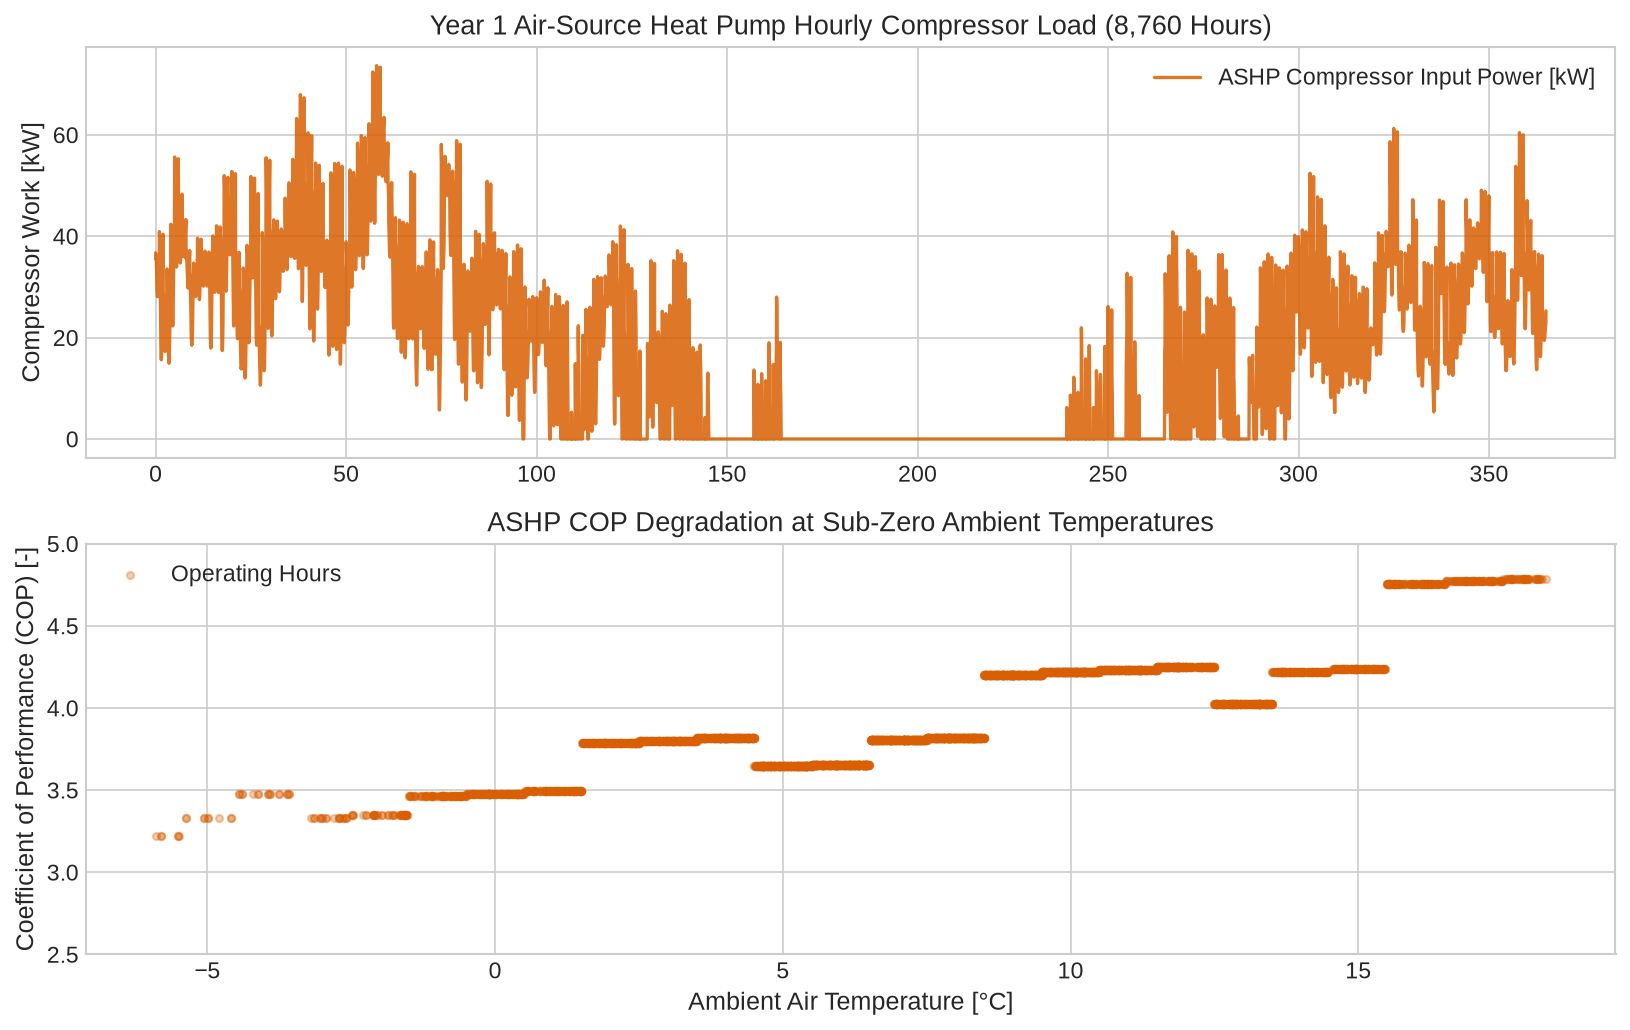

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

# 1. First year compressor load profile (8,760 hours)
time_days_1yr = df_hl['time_days'][:8760]
ax1.plot(time_days_1yr, df_as['W_total_kW'][:8760], color='#d95f02', alpha=0.85, label='ASHP Compressor Input Power [kW]')
ax1.set_ylabel('Compressor Work [kW]')
ax1.set_title('Year 1 Air-Source Heat Pump Hourly Compressor Load (8,760 Hours)')
ax1.legend(loc='upper right')

# 2. COP vs Ambient External Air Temperature
ax2.scatter(df_hl.loc[active_mask, 'external_temp_C'][:5000], df_as.loc[active_mask, 'COP'][:5000], 
            color='#d95f02', alpha=0.3, s=12, label='Operating Hours')
ax2.set_xlabel('Ambient Air Temperature [°C]')
ax2.set_ylabel('Coefficient of Performance (COP) [-]')
ax2.set_title('ASHP COP Degradation at Sub-Zero Ambient Temperatures')
ax2.set_ylim(2.5, 5.0)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


## 6. Summary & Engineering Takeaways
- **Vulnerability to Cold Snaps**: When ambient air temperatures drop below $0^\circ\text{C}$ in January/February, the evaporator saturation pressure drops significantly, increasing the compression pressure ratio and driving compressor power up to its peak of **82.04 kW**.
- **Defrosting & Cycling**: Sub-zero operation requires frequent defrost cycles (not modeled here), further impacting real-world seasonal efficiency compared to decoupled ground or water thermal sinks.
